In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from IPython.display import display
import matplotlib.pyplot as plt

base = Path(r'C:\Users\Eric\OneDrive\Desktop\p\U\introduccion-progrmacion-cientifica-')
path = base / 'data' / 'game_info.csv'
df = pd.read_csv(path)

print(f'Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
print('Primeros 5 registros:')
display(df.head())
print('Tipos de datos:')
display(df.dtypes)


Matplotlib is building the font cache; this may take a moment.


Filas: 474417 | Columnas: 27
Primeros 5 registros:


,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17T11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06T23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22T13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28T22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17T13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0


Tipos de datos:


id                        int64
slug                        str
name                        str
metacritic              float64
released                    str
tba                        bool
updated                     str
website                     str
rating                  float64
rating_top                int64
playtime                  int64
achievements_count        int64
ratings_count             int64
suggestions_count         int64
game_series_count         int64
reviews_count             int64
platforms                   str
developers                  str
genres                      str
publishers                  str
esrb_rating                 str
added_status_yet          int64
added_status_owned        int64
added_status_beaten       int64
added_status_toplay       int64
added_status_dropped      int64
added_status_playing      int64
dtype: object

In [2]:
df_clean = df.copy()

for col in ['slug', 'name', 'website', 'platforms', 'developers', 'genres', 'publishers']:
    df_clean[col] = df_clean[col].replace('', np.nan)

df_clean['released'] = pd.to_datetime(df_clean['released'], errors='coerce')
df_clean['updated'] = pd.to_datetime(df_clean['updated'], errors='coerce')
df_clean['rating'] = pd.to_numeric(df_clean['rating'], errors='coerce')
df_clean['metacritic'] = pd.to_numeric(df_clean['metacritic'], errors='coerce')
df_clean['playtime'] = pd.to_numeric(df_clean['playtime'], errors='coerce')

print('Datos limpios:')
display(df_clean.head())
print(f'Valores faltantes totales: {df_clean.isna().sum().sum()}')
print('Resumen de nulos por columna:')
display(df_clean.isna().sum().sort_values(ascending=False).head(10))


Datos limpios:


,id,slug,name,metacritic,released,tba,updated,website,rating,rating_top,...,developers,genres,publishers,esrb_rating,added_status_yet,added_status_owned,added_status_beaten,added_status_toplay,added_status_dropped,added_status_playing
0,1,dgeneration-hd,D/Generation HD,NaN,2015-10-23,False,2019-09-17 11:58:57,http://dgeneration.net,0.0,0,...,West Coast Software,Adventure||Puzzle,West Coast Software,Everyone 10+,4,88,2,2,0,0
1,10,g-prime,G Prime Into The Rain,NaN,2016-01-06,False,2019-11-06 23:04:19,NaN,0.0,0,...,Soma Games,Simulation||Indie,Immanitas Entertainment||Code-Monkeys,Everyone,2,42,2,0,0,0
2,100,land-sliders,Land Sliders,NaN,2015-09-24,False,2019-10-22 13:56:16,http://prettygreat.com,0.0,0,...,Prettygreat Pty,Adventure||Arcade,Prettygreat Pty,Everyone 10+,0,2,2,0,1,0
3,1000,pixel-gear,Pixel Gear,NaN,2016-10-20,False,2019-08-28 22:16:02,https://www.facebook.com/Geronimo-Interactive-...,0.0,0,...,Oasis Games||Geronimo Interactive,Action||Indie,Geronimo Interactive,Teen,0,1,0,0,0,0
4,10000,gods-and-idols,Gods and Idols,NaN,2016-12-12,False,2019-09-17 13:37:13,http://www.godsandidols.com/,0.0,1,...,Viking Tao,RPG||Strategy||Massively Multiplayer,Viking Tao,NaN,2,79,0,0,0,0


Valores faltantes totales: 1770755
Resumen de nulos por columna:


metacritic     469684
esrb_rating    418553
website        409376
publishers     333401
genres         103185
released        24199
developers       8366
platforms        3986
name                3
slug                2
dtype: int64

In [3]:
numericas = ['rating', 'metacritic', 'playtime', 'ratings_count', 'suggestions_count', 'reviews_count']
summary = df_clean[numericas].describe().T
display(summary)

print('Promedio de rating:', round(float(df_clean['rating'].mean()), 3))
print('Juegos con mejor rating:')
display(df_clean.sort_values('rating', ascending=False).head(10)[['id', 'name', 'rating', 'released', 'genres']])

print('Distribuci?n por a?o de lanzamiento:')
by_year = df_clean['released'].dt.year.value_counts().sort_index()
display(by_year.head(10))


,count,mean,std,min,25%,50%,75%,max
rating,474417.0,0.085723,0.545049,0.0,0.0,0.0,0.0,5.0
metacritic,4733.0,73.159307,11.502213,15.0,67.0,75.0,81.0,99.0
playtime,474417.0,0.221662,5.399684,0.0,0.0,0.0,0.0,1600.0
ratings_count,474417.0,2.142463,36.553606,0.0,0.0,0.0,0.0,4289.0
suggestions_count,474417.0,92.196848,116.493695,0.0,16.0,47.0,122.0,1839.0
reviews_count,474417.0,2.162783,36.868160,0.0,0.0,0.0,0.0,4334.0


Promedio de rating: 0.086
Juegos con mejor rating:


,id,name,rating,released,genres
282544,388309,Diablo IV,5.00,NaT,Action||RPG
33966,132,The World Ends with You: Solo Remix,4.86,2012-08-27,Action||RPG
158411,257281,Kara no Shojo,4.83,2018-10-22,Adventure
433026,53135,Astro Boy: Omega Factor,4.83,2003-12-18,NaN
133647,229144,Hide Online,4.83,NaT,Action
240990,339958,Persona 5 Royal,4.81,2020-03-31,Adventure||RPG
287091,392459,Shovel Knight: Shovel of Hope,4.78,2014-06-26,Action||Adventure||Indie
158384,257255,The Witcher 3: Game of the Year,4.77,2016-08-30,Adventure||RPG
313592,4167,Mass Effect Trilogy,4.76,2012-11-06,Action||Shooter||RPG
11648,1111,METAL GEAR SOLID V: THE DEFINITIVE EXPERIENCE,4.75,2016-10-11,Action


Distribuci?n por a?o de lanzamiento:


released
1962.0     1
1970.0     1
1971.0     5
1972.0     1
1973.0     1
1974.0     1
1975.0     2
1976.0     7
1977.0    12
1978.0    16
Name: count, dtype: int64

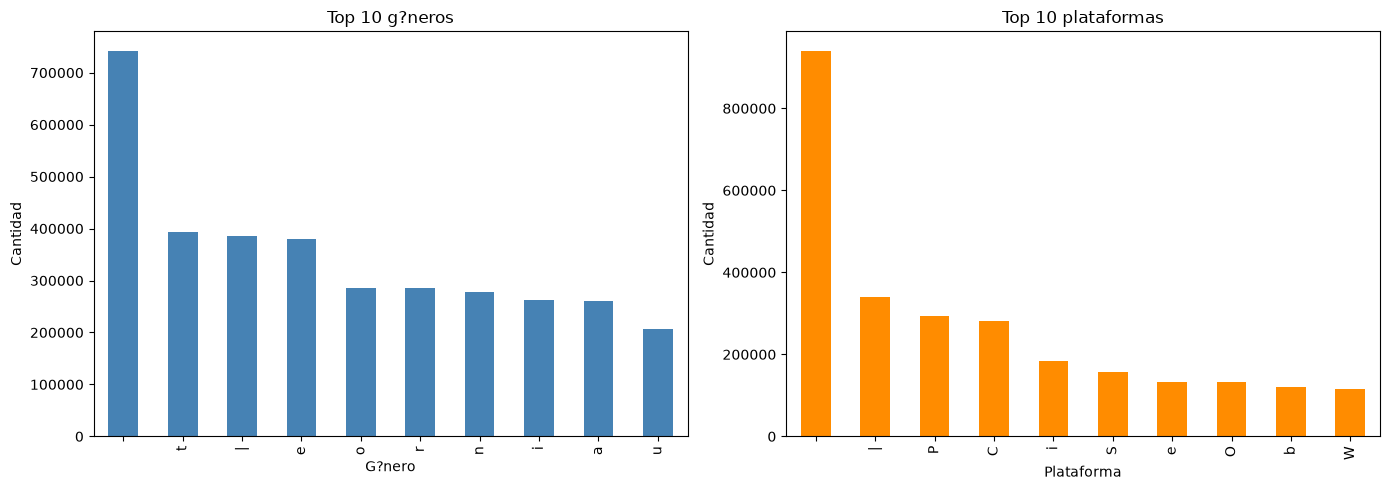

In [4]:
import matplotlib.pyplot as plt

top_genres = df_clean['genres'].dropna().str.split('||').explode().value_counts().head(10)
top_platforms = df_clean['platforms'].dropna().str.split('||').explode().value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_genres.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top 10 g?neros')
axes[0].set_xlabel('G?nero')
axes[0].set_ylabel('Cantidad')

top_platforms.plot(kind='bar', ax=axes[1], color='darkorange')
axes[1].set_title('Top 10 plataformas')
axes[1].set_xlabel('Plataforma')
axes[1].set_ylabel('Cantidad')

plt.tight_layout()
plt.show()


In [5]:
output_path = base / 'data' / 'game_info_cleaned.csv'
df_clean.to_csv(output_path, index=False)

summary = {
    'filas': int(df_clean.shape[0]),
    'columnas': int(df_clean.shape[1]),
    'rating_promedio': round(float(df_clean['rating'].mean()), 3),
    'metacritic_promedio': round(float(df_clean['metacritic'].mean()), 3),
    'fecha_min': str(df_clean['released'].min().date()),
    'fecha_max': str(df_clean['released'].max().date()),
}

print('Archivo exportado:', output_path)
print('Resumen general:')
for k, v in summary.items():
    print(f'{k}: {v}')


Archivo exportado: C:\Users\Eric\OneDrive\Desktop\p\U\introduccion-progrmacion-cientifica-\data\game_info_cleaned.csv
Resumen general:
filas: 474417
columnas: 27
rating_promedio: 0.086
metacritic_promedio: 73.159
fecha_min: 1962-01-01
fecha_max: 2033-01-03
